In [119]:
import boto3
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sagemaker
from sagemaker import AutoML

bucket = "amzn-s3-netflixbucket-ads508"
key = "archive (1).zip"

s3 = boto3.client("s3")

# download zip from S3
s3.download_file(bucket, key, "netflix_dataset.zip")

# unzip
with zipfile.ZipFile("netflix_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("netflix_data")

print("Files extracted successfully")

Files extracted successfully


In [120]:

os.makedirs("dataprep", exist_ok=True)
os.makedirs("training", exist_ok=True)

print("Folders created or already exist.")
print("dataprep exists:", os.path.exists("dataprep"))
print("training exists:", os.path.exists("training"))

Folders created or already exist.
dataprep exists: True
training exists: True


In [121]:
### COMBINED DATA 1
with open("netflix_data/combined_data_1.txt", "r") as f:
    for _ in range(15):
        print(f.readline().strip())

1:
1488844,3,2005-09-06
822109,5,2005-05-13
885013,4,2005-10-19
30878,4,2005-12-26
823519,3,2004-05-03
893988,3,2005-11-17
124105,4,2004-08-05
1248029,3,2004-04-22
1842128,4,2004-05-09
2238063,3,2005-05-11
1503895,4,2005-05-19
2207774,5,2005-06-06
2590061,3,2004-08-12
2442,3,2004-04-14


In [122]:
# Note: AI assistance was used to improve speed, clarity, and readability in for parsing section due to size of the txt data file.
records = []
current_movie = None

with open("netflix_data/combined_data_1.txt", "r") as f:
    for line in f:
        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])
        else:
            user_id, rating, date = line.split(",")
            records.append([current_movie, int(user_id), int(rating), date])

        if len(records) >= 100000:  # sample only (faster)
            break

ratings = pd.DataFrame(records, columns=["movie_id","user_id","rating","date"])

ratings.head()

,movie_id,user_id,rating,date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


In [123]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   movie_id  100000 non-null  int64 
 1   user_id   100000 non-null  int64 
 2   rating    100000 non-null  int64 
 3   date      100000 non-null  object
dtypes: int64(3), object(1)
memory usage: 3.1+ MB


In [124]:
clean_ratings = ratings.copy()

clean_ratings["date"] = pd.to_datetime(clean_ratings["date"], errors="coerce")

clean_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  100000 non-null  int64         
 1   user_id   100000 non-null  int64         
 2   rating    100000 non-null  int64         
 3   date      100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 3.1 MB


In [125]:
clean_ratings.isnull().sum()

movie_id    0
user_id     0
rating      0
date        0
dtype: int64

In [126]:
clean_ratings["rating"].value_counts().sort_index()

rating
1     5920
2    10949
3    28619
4    33021
5    21491
Name: count, dtype: int64

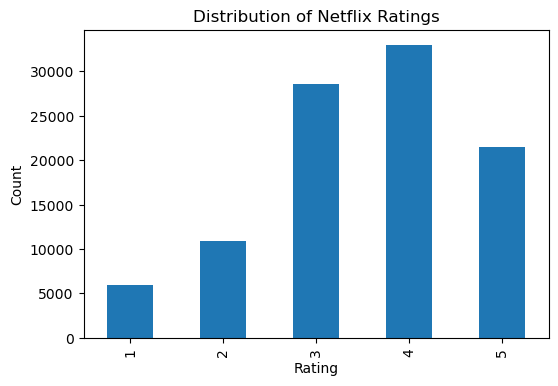

In [127]:
plt.figure(figsize=(6,4))
clean_ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

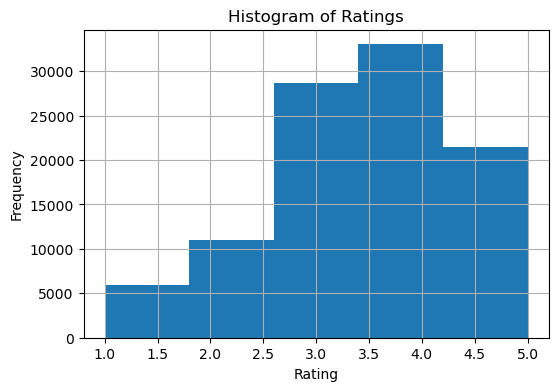

In [128]:
plt.figure(figsize=(6,4))

clean_ratings["rating"].hist(bins=5)

plt.title("Histogram of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

In [129]:
clean_ratings["year"] = clean_ratings["date"].dt.year
clean_ratings.head()

,movie_id,user_id,rating,date,year
0,1,1488844,3,2005-09-06,2005
1,1,822109,5,2005-05-13,2005
2,1,885013,4,2005-10-19,2005
3,1,30878,4,2005-12-26,2005
4,1,823519,3,2004-05-03,2004


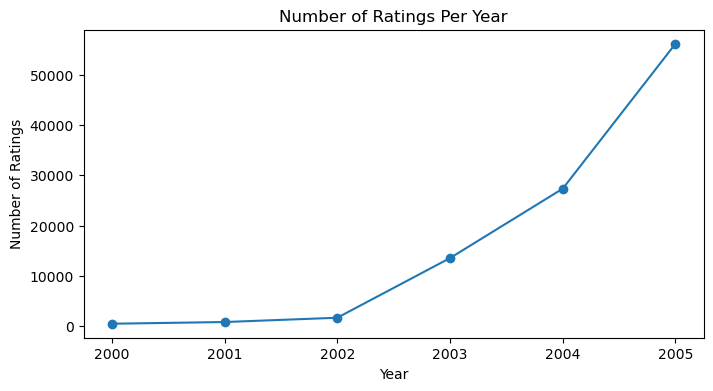

In [130]:
ratings_per_year = clean_ratings["year"].value_counts().sort_index()

plt.figure(figsize=(8,4))

ratings_per_year.plot(kind="line", marker="o")

plt.title("Number of Ratings Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.show()

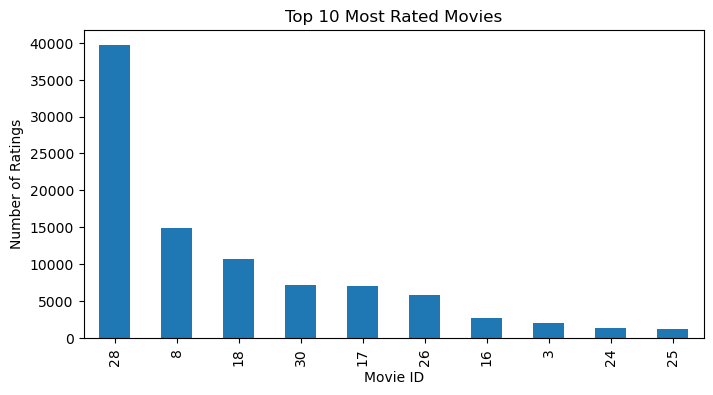

In [131]:
top_movies = (
    clean_ratings.groupby("movie_id").size().sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))

top_movies.plot(kind="bar")

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")

plt.show()

In [132]:
clean_ratings.duplicated().sum()

0

In [133]:
movie_avg_rating = (
    clean_ratings.groupby("movie_id")["rating"]
    .mean()
    .sort_values(ascending=False)
)

movie_avg_rating.head(10)

movie_id
13    4.552000
25    3.970174
5     3.919298
28    3.823254
18    3.784369
30    3.757706
1     3.749543
3     3.641153
29    3.598470
2     3.558621
Name: rating, dtype: float64

In [134]:
user_avg_rating = (
    clean_ratings.groupby("user_id")["rating"]
    .mean()
)
user_avg_rating

user_id
7          4.5
134        5.0
201        4.0
261        4.0
265        3.0
          ... 
2649331    5.0
2649336    4.0
2649375    4.0
2649378    3.0
2649426    4.0
Name: rating, Length: 81490, dtype: float64

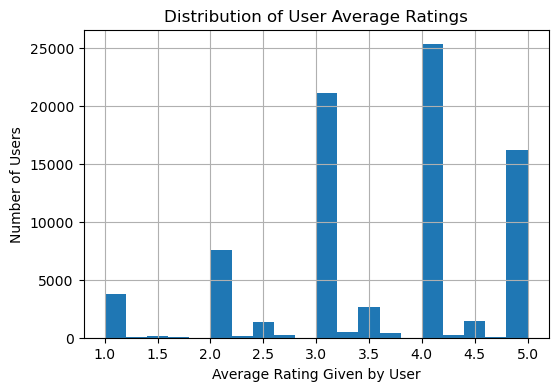

In [135]:
plt.figure(figsize=(6,4))

user_avg_rating.hist(bins=20)

plt.title("Distribution of User Average Ratings")
plt.xlabel("Average Rating Given by User")
plt.ylabel("Number of Users")

plt.show()

In [136]:
movie_stats = clean_ratings.groupby("movie_id").agg(
    rating_count=("rating","count"),
    avg_rating=("rating","mean")
)
movie_stats

,rating_count,avg_rating
movie_id,,
1,547,3.749543
2,145,3.558621
3,2012,3.641153
4,142,2.739437
5,1140,3.919298
6,1019,3.084396
7,93,2.129032
8,14910,3.189805
9,95,2.621053


In [137]:
clean_ratings[["movie_id","user_id","rating"]].corr()

,movie_id,user_id,rating
movie_id,1.000000,-0.003074,0.165171
user_id,-0.003074,1.000000,0.002443
rating,0.165171,0.002443,1.000000


In [138]:
print("Unique users:", clean_ratings["user_id"].nunique())
print("Unique movies:", clean_ratings["movie_id"].nunique())
print("Total ratings:", len(clean_ratings))

Unique users: 81490
Unique movies: 30
Total ratings: 100000


In [139]:
with open("netflix_data/combined_data_2.txt", "r") as f:
    for _ in range(15):
        print(f.readline().strip())

4500:
2532865,4,2005-07-26
573364,3,2005-06-20
1696725,3,2004-02-27
1253431,3,2004-03-31
1265574,2,2003-09-01
1049643,1,2003-11-15
1601348,4,2005-04-05
1495289,5,2005-07-09
1254903,3,2003-09-02
2604070,3,2005-05-15
1006473,5,2005-05-23
1989892,3,2004-04-06
1517471,4,2003-12-24
1478381,4,2005-05-21


In [140]:
# COMBINED DATA 2
records2 = []
current_movie = None

with open("netflix_data/combined_data_2.txt", "r") as f:
    for line in f:
        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])
        else:
            user_id, rating, date = line.split(",")
            records2.append([current_movie, int(user_id), int(rating), date])

        if len(records2) >= 100000:  # sample for speed
            break

ratings2 = pd.DataFrame(
    records2,
    columns=["movie_id", "user_id", "rating", "date"]
)

ratings2.head()

,movie_id,user_id,rating,date
0,4500,2532865,4,2005-07-26
1,4500,573364,3,2005-06-20
2,4500,1696725,3,2004-02-27
3,4500,1253431,3,2004-03-31
4,4500,1265574,2,2003-09-01


In [141]:
ratings2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   movie_id  100000 non-null  int64 
 1   user_id   100000 non-null  int64 
 2   rating    100000 non-null  int64 
 3   date      100000 non-null  object
dtypes: int64(3), object(1)
memory usage: 3.1+ MB


In [142]:
ratings2.isnull().sum()

movie_id    0
user_id     0
rating      0
date        0
dtype: int64

In [143]:
ratings2["rating"].value_counts().sort_index()

rating
1     4271
2     9364
3    28058
4    33714
5    24593
Name: count, dtype: int64

In [144]:
ratings2.duplicated().sum()

0

In [145]:
ratings2["date"] = pd.to_datetime(ratings2["date"], errors="coerce")
ratings2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  100000 non-null  int64         
 1   user_id   100000 non-null  int64         
 2   rating    100000 non-null  int64         
 3   date      100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 3.1 MB


In [146]:
combined_ratings = pd.concat([clean_ratings, ratings2], ignore_index=True)
combined_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  200000 non-null  int64         
 1   user_id   200000 non-null  int64         
 2   rating    200000 non-null  int64         
 3   date      200000 non-null  datetime64[ns]
 4   year      100000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 7.6 MB


In [147]:
clean_ratings.head()

,movie_id,user_id,rating,date,year
0,1,1488844,3,2005-09-06,2005
1,1,822109,5,2005-05-13,2005
2,1,885013,4,2005-10-19,2005
3,1,30878,4,2005-12-26,2005
4,1,823519,3,2004-05-03,2004


In [148]:
combined_ratings = combined_ratings.drop(columns=["year"], errors="ignore")
combined_ratings["year"] = combined_ratings["date"].dt.year
combined_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  200000 non-null  int64         
 1   user_id   200000 non-null  int64         
 2   rating    200000 non-null  int64         
 3   date      200000 non-null  datetime64[ns]
 4   year      200000 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3)
memory usage: 6.9 MB


In [149]:
#combined 3 
with open("netflix_data/combined_data_3.txt", "r") as f:
    for _ in range(15):
        print(f.readline().strip())

9211:
1277134,1,2003-12-02
2435457,2,2005-06-01
2338545,3,2001-02-17
2218269,1,2002-12-27
441153,4,2002-10-11
1921624,2,2005-08-31
2096652,3,2004-05-31
818736,2,2004-02-17
284560,3,2003-07-27
1211224,5,2004-05-08
1984086,1,2004-09-16
1389539,3,2005-06-07
454575,2,2004-10-23
149028,3,2003-06-19


In [150]:
records3 = []
current_movie = None

with open("netflix_data/combined_data_3.txt", "r") as f:
    for line in f:
        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])
        else:
            user_id, rating, date = line.split(",")
            records3.append([current_movie, int(user_id), int(rating), date])

        if len(records3) >= 100000:
            break

ratings3 = pd.DataFrame(
    records3,
    columns=["movie_id", "user_id", "rating", "date"]
)

ratings3.head()

,movie_id,user_id,rating,date
0,9211,1277134,1,2003-12-02
1,9211,2435457,2,2005-06-01
2,9211,2338545,3,2001-02-17
3,9211,2218269,1,2002-12-27
4,9211,441153,4,2002-10-11


In [151]:
ratings3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   movie_id  100000 non-null  int64 
 1   user_id   100000 non-null  int64 
 2   rating    100000 non-null  int64 
 3   date      100000 non-null  object
dtypes: int64(3), object(1)
memory usage: 3.1+ MB


In [152]:
ratings3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   movie_id  100000 non-null  int64 
 1   user_id   100000 non-null  int64 
 2   rating    100000 non-null  int64 
 3   date      100000 non-null  object
dtypes: int64(3), object(1)
memory usage: 3.1+ MB


In [153]:
ratings3.isnull().sum()

movie_id    0
user_id     0
rating      0
date        0
dtype: int64

In [154]:
ratings3["rating"].value_counts().sort_index()

rating
1     6324
2    13253
3    34749
4    29973
5    15701
Name: count, dtype: int64

In [155]:
ratings3["date"] = pd.to_datetime(ratings3["date"], errors="coerce")
ratings3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  100000 non-null  int64         
 1   user_id   100000 non-null  int64         
 2   rating    100000 non-null  int64         
 3   date      100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 3.1 MB


In [156]:
combined_ratings = pd.concat([clean_ratings, ratings3], ignore_index=True)
combined_ratings = combined_ratings.drop(columns=["year"], errors="ignore")
combined_ratings["year"] = combined_ratings["date"].dt.year
combined_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  200000 non-null  int64         
 1   user_id   200000 non-null  int64         
 2   rating    200000 non-null  int64         
 3   date      200000 non-null  datetime64[ns]
 4   year      200000 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3)
memory usage: 6.9 MB


In [157]:
print(len(clean_ratings))
print(len(ratings3))
print(len(combined_ratings))

100000
100000
200000


In [158]:
combined_ratings = pd.concat([clean_ratings, ratings2, ratings3], ignore_index=True)
combined_ratings = combined_ratings.drop(columns=["year"], errors="ignore")
combined_ratings["year"] = combined_ratings["date"].dt.year

combined_ratings.info()
print(len(combined_ratings))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  300000 non-null  int64         
 1   user_id   300000 non-null  int64         
 2   rating    300000 non-null  int64         
 3   date      300000 non-null  datetime64[ns]
 4   year      300000 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3)
memory usage: 10.3 MB
300000


In [159]:
clean_ratings = combined_ratings.copy()

In [160]:
with open("netflix_data/combined_data_4.txt", "r") as f:
    for _ in range(15):
        print(f.readline().strip())

13368:
2385003,4,2004-07-08
659432,3,2005-03-16
751812,2,2002-12-16
2625420,2,2004-05-25
1650301,1,2005-08-30
2269227,4,2005-10-27
2220672,4,2002-08-19
2500511,4,2003-08-11
1452058,2,2005-01-29
1624891,3,2002-07-27
970031,3,2004-04-14
345673,4,2005-04-07
1426869,5,2005-04-21
1037088,2,2005-09-14


In [161]:
records4 = []
current_movie = None

with open("netflix_data/combined_data_4.txt", "r") as f:
    for line in f:
        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])
        else:
            user_id, rating, date = line.split(",")
            records4.append([current_movie, int(user_id), int(rating), date])

        if len(records4) >= 100000:
            break

ratings4 = pd.DataFrame(
    records4,
    columns=["movie_id", "user_id", "rating", "date"]
)

ratings4.head()

,movie_id,user_id,rating,date
0,13368,2385003,4,2004-07-08
1,13368,659432,3,2005-03-16
2,13368,751812,2,2002-12-16
3,13368,2625420,2,2004-05-25
4,13368,1650301,1,2005-08-30


In [162]:
ratings4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   movie_id  100000 non-null  int64 
 1   user_id   100000 non-null  int64 
 2   rating    100000 non-null  int64 
 3   date      100000 non-null  object
dtypes: int64(3), object(1)
memory usage: 3.1+ MB


In [163]:
ratings4.isnull().sum()

movie_id    0
user_id     0
rating      0
date        0
dtype: int64

In [164]:
ratings4["rating"].value_counts().sort_index()

rating
1     3230
2     8054
3    29593
4    37598
5    21525
Name: count, dtype: int64

In [165]:
ratings4["date"] = pd.to_datetime(ratings4["date"], errors="coerce")
ratings4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  100000 non-null  int64         
 1   user_id   100000 non-null  int64         
 2   rating    100000 non-null  int64         
 3   date      100000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 3.1 MB


In [166]:
combined_ratings = pd.concat([ratings, ratings2, ratings3, ratings4], ignore_index=True)
combined_ratings["date"] = pd.to_datetime(combined_ratings["date"], errors="coerce")
combined_ratings["year"] = combined_ratings["date"].dt.year

combined_ratings.info()
print("Total rows:", len(combined_ratings))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   movie_id  400000 non-null  int64         
 1   user_id   400000 non-null  int64         
 2   rating    400000 non-null  int64         
 3   date      400000 non-null  datetime64[ns]
 4   year      400000 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3)
memory usage: 13.7 MB
Total rows: 400000


In [167]:
combined_ratings.isnull().sum()

movie_id    0
user_id     0
rating      0
date        0
year        0
dtype: int64

In [168]:
combined_ratings["rating"].value_counts().sort_index()

rating
1     19745
2     41620
3    121019
4    134306
5     83310
Name: count, dtype: int64

In [169]:
combined_ratings.duplicated().sum()

0

In [170]:
print("Total ratings:", len(combined_ratings))
print("Unique users:", combined_ratings["user_id"].nunique())
print("Unique movies:", combined_ratings["movie_id"].nunique())
print("Date range:", combined_ratings["date"].min(), "to", combined_ratings["date"].max())

Total ratings: 400000
Unique users: 172458
Unique movies: 101
Date range: 1999-12-31 00:00:00 to 2005-12-31 00:00:00


In [171]:
clean_ratings = combined_ratings.copy()

In [172]:
clean_ratings.head(10)

,movie_id,user_id,rating,date,year
0,1,1488844,3,2005-09-06,2005
1,1,822109,5,2005-05-13,2005
2,1,885013,4,2005-10-19,2005
3,1,30878,4,2005-12-26,2005
4,1,823519,3,2004-05-03,2004
5,1,893988,3,2005-11-17,2005
6,1,124105,4,2004-08-05,2004
7,1,1248029,3,2004-04-22,2004
8,1,1842128,4,2004-05-09,2004
9,1,2238063,3,2005-05-11,2005


In [173]:
combined_ratings.to_csv("dataprep/netflix_combined_ratings.csv", index=False)
print("CSV saved successfully")

CSV saved successfully


In [174]:
pd.read_csv("dataprep/netflix_combined_ratings.csv").head()

,movie_id,user_id,rating,date,year
0,1,1488844,3,2005-09-06,2005
1,1,822109,5,2005-05-13,2005
2,1,885013,4,2005-10-19,2005
3,1,30878,4,2005-12-26,2005
4,1,823519,3,2004-05-03,2004


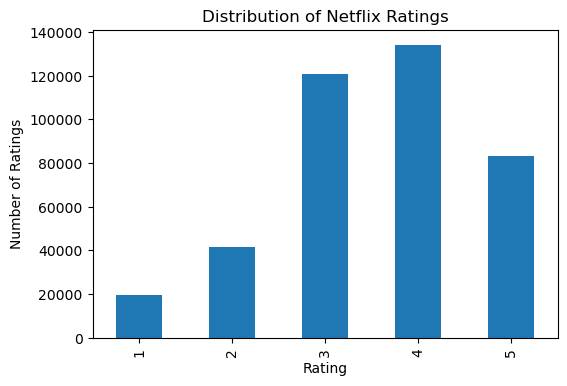

In [175]:
plt.figure(figsize=(6,4))
combined_ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

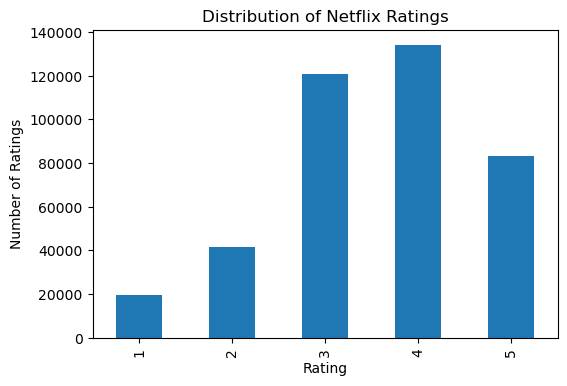

In [176]:
plt.figure(figsize=(6,4))
combined_ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

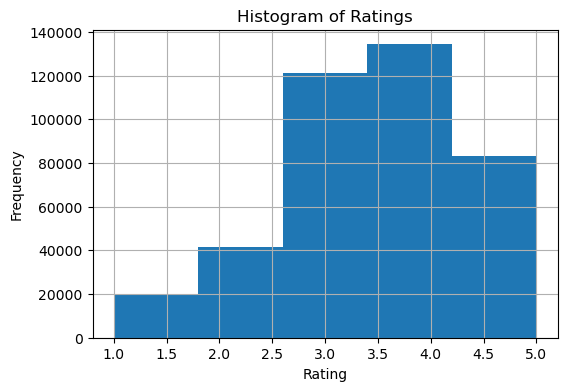

In [177]:
plt.figure(figsize=(6,4))
combined_ratings["rating"].hist(bins=5)
plt.title("Histogram of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

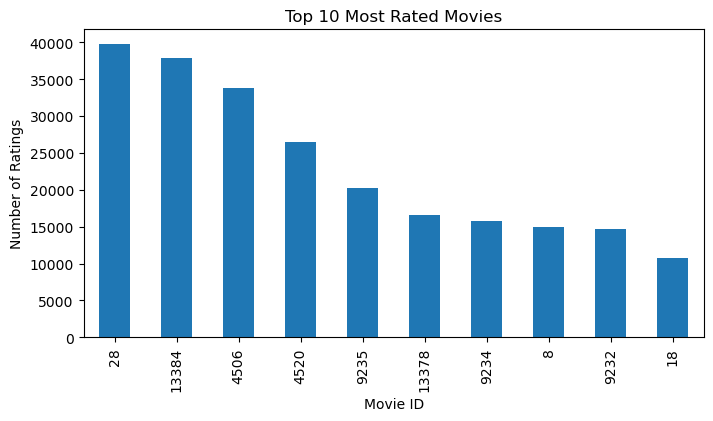

In [178]:
top_movies = (combined_ratings.groupby("movie_id").size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))
top_movies.plot(kind="bar")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

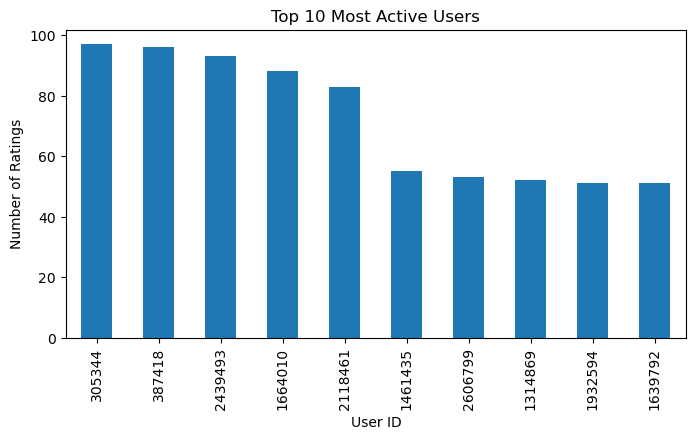

In [179]:
top_users = (combined_ratings.groupby("user_id").size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))
top_users.plot(kind="bar")
plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.show()

In [180]:
print("Total ratings:", len(combined_ratings))
print("Unique users:", combined_ratings["user_id"].nunique())
print("Unique movies:", combined_ratings["movie_id"].nunique())
print("Date range:", combined_ratings["date"].min(), "to", combined_ratings["date"].max())

Total ratings: 400000
Unique users: 172458
Unique movies: 101
Date range: 1999-12-31 00:00:00 to 2005-12-31 00:00:00


In [181]:
with open("netflix_data/movie_titles.csv", "r", encoding="latin-1") as f:
    for _ in range(10):
        print(f.readline().strip())

1,2003,Dinosaur Planet
2,2004,Isle of Man TT 2004 Review
3,1997,Character
4,1994,Paula Abdul's Get Up & Dance
5,2004,The Rise and Fall of ECW
6,1997,Sick
7,1992,8 Man
8,2004,What the #$*! Do We Know!?
9,1991,Class of Nuke 'Em High 2
10,2001,Fighter


In [182]:
movie_rows = []

with open("netflix_data/movie_titles.csv", "r", encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split(",", 2)   # split into at most 3 parts
        if len(parts) == 3:
            movie_id, release_year, title = parts
            movie_rows.append([movie_id, release_year, title])

movies = pd.DataFrame(movie_rows, columns=["movie_id", "release_year", "title"])

movies["movie_id"] = pd.to_numeric(movies["movie_id"], errors="coerce")
movies["release_year"] = pd.to_numeric(movies["release_year"], errors="coerce")

movies.head()

,movie_id,release_year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [183]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      17770 non-null  int64  
 1   release_year  17763 non-null  float64
 2   title         17770 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 416.6+ KB


In [184]:
movies.isnull().sum()

movie_id        0
release_year    7
title           0
dtype: int64

In [185]:
movies["movie_id"].duplicated().sum()

0

In [186]:
movies[movies["release_year"].isnull()]

,movie_id,release_year,title
4387,4388,NaN,Ancient Civilizations: Rome and Pompeii
4793,4794,NaN,Ancient Civilizations: Land of the Pharaohs
7240,7241,NaN,Ancient Civilizations: Athens and Greece
10781,10782,NaN,Roti Kapada Aur Makaan
15917,15918,NaN,Hote Hote Pyaar Ho Gaya
16677,16678,NaN,Jimmy Hollywood
17666,17667,NaN,Eros Dance Dhamaka


In [187]:
movies["release_year"] = movies["release_year"].fillna(movies["release_year"].median())
movies["release_year"] = movies["release_year"].astype(int)

In [188]:
movies[movies["release_year"].isnull()]

,movie_id,release_year,title


In [189]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movie_id      17770 non-null  int64 
 1   release_year  17770 non-null  int64 
 2   title         17770 non-null  object
dtypes: int64(2), object(1)
memory usage: 416.6+ KB


In [190]:
movies.isnull().sum()

movie_id        0
release_year    0
title           0
dtype: int64

In [191]:
movies["movie_id"].duplicated().sum()

0

In [192]:
movies["release_year"].describe()

count    17770.000000
mean      1990.266348
std         16.505180
min       1896.000000
25%       1985.000000
50%       1997.000000
75%       2002.000000
max       2005.000000
Name: release_year, dtype: float64

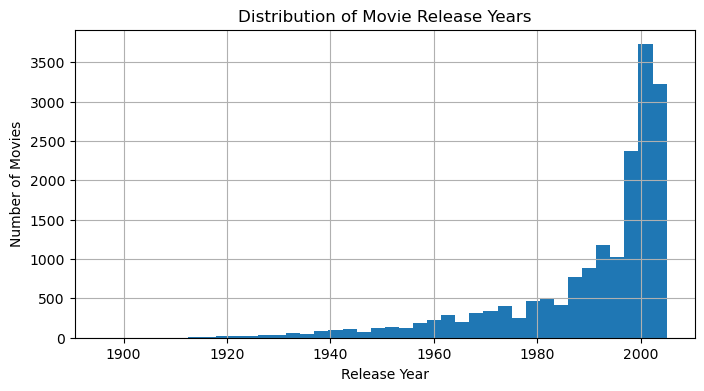

In [193]:
plt.figure(figsize=(8,4))
movies["release_year"].hist(bins=40)

plt.title("Distribution of Movie Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

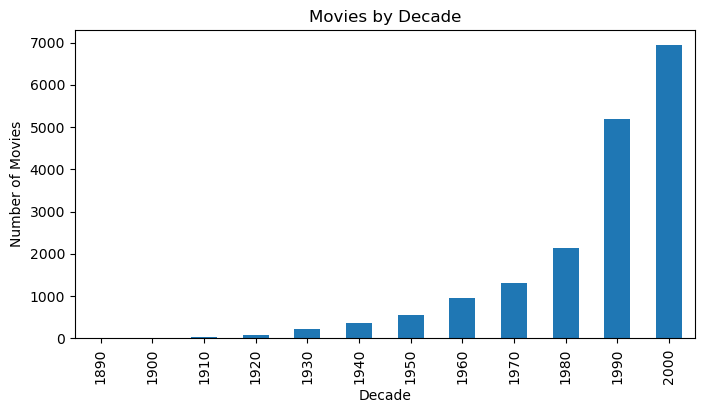

In [194]:
movies["decade"] = (movies["release_year"] // 10) * 10
decade_counts = movies["decade"].value_counts().sort_index()

plt.figure(figsize=(8,4))
decade_counts.plot(kind="bar")
plt.title("Movies by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")

plt.show()

In [195]:
movie_titles_output_path = "dataprep/movie_titles_cleaned.csv"
movies.to_csv(movie_titles_output_path, index=False)
print("Saved to:", movie_titles_output_path)

Saved to: dataprep/movie_titles_cleaned.csv


In [196]:
with open("netflix_data/probe.txt", "r") as f:
    for _ in range(20):
        print(f.readline().strip())

1:
30878
2647871
1283744
2488120
317050
1904905
1989766
14756
1027056
1149588
1394012
1406595
2529547
1682104
2625019
2603381
1774623
470861
712610


In [197]:
probe_records = []
current_movie = None

with open("netflix_data/probe.txt", "r") as f:
    for line in f:
        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])
        else:
            user_id = int(line)
            probe_records.append([current_movie, user_id])

        if len(probe_records) >= 10000:
            break

probe_df = pd.DataFrame(probe_records, columns=["movie_id", "user_id"])

probe_df.head()

,movie_id,user_id
0,1,30878
1,1,2647871
2,1,1283744
3,1,2488120
4,1,317050


In [198]:
probe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  10000 non-null  int64
 1   user_id   10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB


In [199]:
probe_df.isnull().sum()

movie_id    0
user_id     0
dtype: int64

In [200]:
probe_df.describe()

,movie_id,user_id
count,10000.000000,1.000000e+04
mean,8931.711700,1.324159e+06
std,3059.658038,7.691310e+05
min,1.000000,4.390000e+02
25%,10042.000000,6.587592e+05
50%,10095.000000,1.328602e+06
75%,10152.000000,1.992378e+06
max,10200.000000,2.649388e+06


In [201]:
probe_df.duplicated().sum()

0

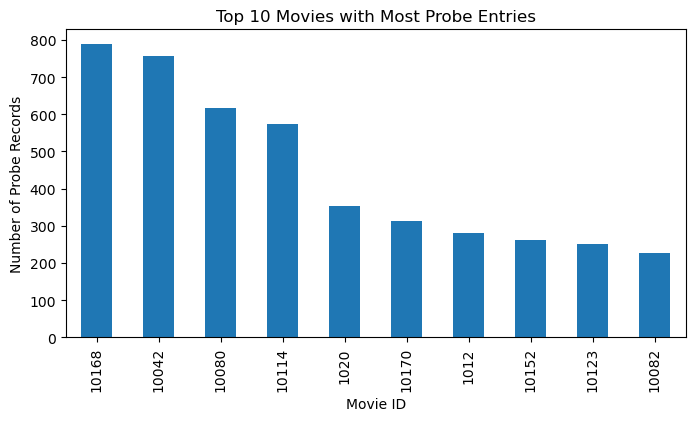

In [202]:
probe_movie_counts = (probe_df.groupby("movie_id").size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))
probe_movie_counts.plot(kind="bar")

plt.title("Top 10 Movies with Most Probe Entries")
plt.xlabel("Movie ID")
plt.ylabel("Number of Probe Records")

plt.show()

In [203]:

probe_output_path = "dataprep/probe_cleaned.csv"
probe_df.to_csv(probe_output_path, index=False)
print("Saved to:", probe_output_path)

Saved to: dataprep/probe_cleaned.csv


In [204]:
with open("netflix_data/qualifying.txt", "r") as f:
    for i in range(20):
        print(i, f.readline().strip())

0 1:
1 1046323,2005-12-19
2 1080030,2005-12-23
3 1830096,2005-03-14
4 368059,2005-05-26
5 802003,2005-11-07
6 513509,2005-07-04
7 1086137,2005-09-21
8 428698,2005-12-20
9 515850,2005-11-27
10 131974,2005-12-15
11 1414572,2005-12-19
12 2112862,2004-12-02
13 1986275,2005-01-22
14 2168239,2005-11-26
15 441146,2005-05-25
16 1687310,2005-09-30
17 1635114,2005-06-06
18 2455305,2005-10-07
19 645660,2005-12-21


In [205]:
qualifying_records = []
current_movie = None

with open("netflix_data/qualifying.txt", "r") as f:
    for line in f:
        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])
        else:
            user_id, date = line.split(",")
            qualifying_records.append([current_movie, int(user_id), date])

        if len(qualifying_records) >= 10000:
            break

qualifying_df = pd.DataFrame(
    qualifying_records,
    columns=["movie_id", "user_id", "date"]
)

qualifying_df.head()

,movie_id,user_id,date
0,1,1046323,2005-12-19
1,1,1080030,2005-12-23
2,1,1830096,2005-03-14
3,1,368059,2005-05-26
4,1,802003,2005-11-07


In [206]:
qualifying_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  10000 non-null  int64 
 1   user_id   10000 non-null  int64 
 2   date      10000 non-null  object
dtypes: int64(2), object(1)
memory usage: 234.5+ KB


In [207]:
qualifying_df.isnull().sum()

movie_id    0
user_id     0
date        0
dtype: int64

In [208]:
qualifying_df["date"] = pd.to_datetime(qualifying_df["date"], errors="coerce")
qualifying_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   movie_id  10000 non-null  int64         
 1   user_id   10000 non-null  int64         
 2   date      10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 234.5 KB


In [209]:
qualifying_output_path = "dataprep/qualifying_cleaned.csv"
qualifying_df.to_csv(qualifying_output_path, index=False)
print("Saved to:", qualifying_output_path)

Saved to: dataprep/qualifying_cleaned.csv


In [210]:
netflix_combined_ratings= pd.read_csv("dataprep/netflix_combined_ratings.csv")
print(netflix_combined_ratings.head())
print(netflix_combined_ratings.info())

   movie_id  user_id  rating        date  year
0         1  1488844       3  2005-09-06  2005
1         1   822109       5  2005-05-13  2005
2         1   885013       4  2005-10-19  2005
3         1    30878       4  2005-12-26  2005
4         1   823519       3  2004-05-03  2004
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   movie_id  400000 non-null  int64 
 1   user_id   400000 non-null  int64 
 2   rating    400000 non-null  int64 
 3   date      400000 non-null  object
 4   year      400000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 15.3+ MB
None


In [211]:
nflix_training_base = netflix_combined_ratings[["user_id", "movie_id", "rating"]].copy()

print(nflix_training_base.head())
print(nflix_training_base.info())
print(nflix_training_base.isnull().sum())
print(nflix_training_base.shape)

   user_id  movie_id  rating
0  1488844         1       3
1   822109         1       5
2   885013         1       4
3    30878         1       4
4   823519         1       3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user_id   400000 non-null  int64
 1   movie_id  400000 non-null  int64
 2   rating    400000 non-null  int64
dtypes: int64(3)
memory usage: 9.2 MB
None
user_id     0
movie_id    0
rating      0
dtype: int64
(400000, 3)


In [212]:
nflix_training_base.to_csv("training/nflix_training_base.csv", index=False)
print("Saved to: training/nflix_training_base.csv")

Saved to: training/nflix_training_base.csv


In [213]:
print(nflix_training_base["rating"].value_counts().sort_index())
print(nflix_training_base.describe())

rating
1     19745
2     41620
3    121019
4    134306
5     83310
Name: count, dtype: int64
            user_id       movie_id         rating
count  4.000000e+05  400000.000000  400000.000000
mean   1.322589e+06    6786.347865       3.549540
std    7.638202e+05    5010.333145       1.080913
min    6.000000e+00       1.000000       1.000000
25%    6.619640e+05    3382.500000       3.000000
50%    1.318518e+06    6866.500000       4.000000
75%    1.982821e+06   10269.000000       4.000000
max    2.649426e+06   13389.000000       5.000000


In [214]:
nflix_training = netflix_combined_ratings[["user_id", "movie_id", "rating", "year"]].copy()
nflix_training.head()

,user_id,movie_id,rating,year
0,1488844,1,3,2005
1,822109,1,5,2005
2,885013,1,4,2005
3,30878,1,4,2005
4,823519,1,3,2004


In [215]:
movies.head()

,movie_id,release_year,title,decade
0,1,2003,Dinosaur Planet,2000
1,2,2004,Isle of Man TT 2004 Review,2000
2,3,1997,Character,1990
3,4,1994,Paula Abdul's Get Up & Dance,1990
4,5,2004,The Rise and Fall of ECW,2000


In [228]:
nflix_training = nflix_training.merge(movies[["movie_id", "title", "release_year"]],
    on="movie_id",
)

In [229]:
nflix_training.to_csv("training/nflix_training.csv", index=False)
print("Saved to: training/nflix_training.csv")

Saved to: training/nflix_training.csv


In [230]:
print(nflix_training_base["rating"].value_counts().sort_index())
print(nflix_training_base.describe())

rating
1     19745
2     41620
3    121019
4    134306
5     83310
Name: count, dtype: int64
            user_id       movie_id         rating
count  4.000000e+05  400000.000000  400000.000000
mean   1.322589e+06    6786.347865       3.549540
std    7.638202e+05    5010.333145       1.080913
min    6.000000e+00       1.000000       1.000000
25%    6.619640e+05    3382.500000       3.000000
50%    1.318518e+06    6866.500000       4.000000
75%    1.982821e+06   10269.000000       4.000000
max    2.649426e+06   13389.000000       5.000000


In [217]:
nflix_training.head()

,user_id,movie_id,rating,year,title,release_year
0,1488844,1,3,2005,Dinosaur Planet,2003
1,822109,1,5,2005,Dinosaur Planet,2003
2,885013,1,4,2005,Dinosaur Planet,2003
3,30878,1,4,2005,Dinosaur Planet,2003
4,823519,1,3,2004,Dinosaur Planet,2003


In [234]:
print(nflix_training.duplicated().sum())

0


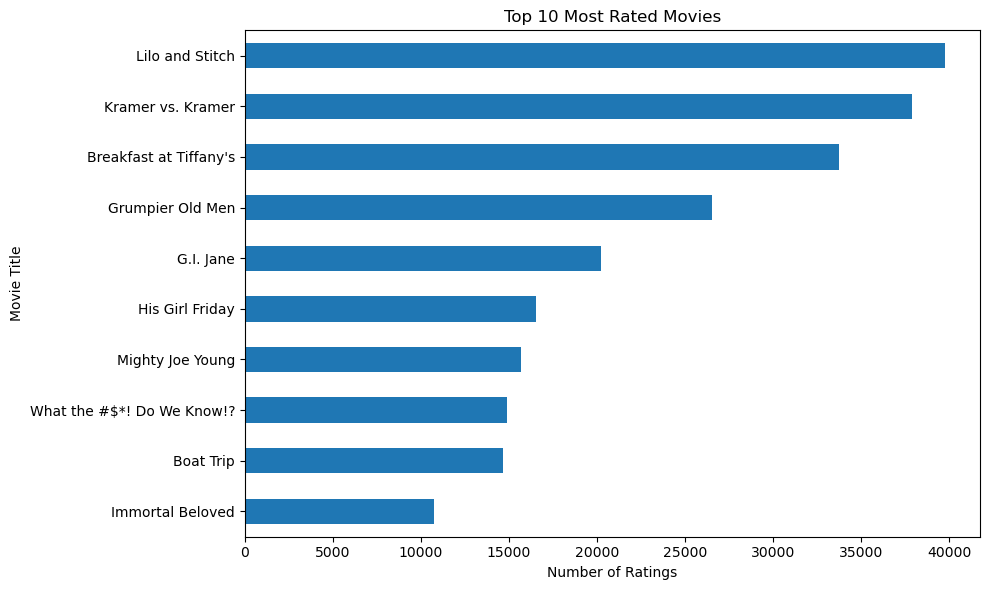

In [226]:
top_movies = (nflix_training["title"].value_counts().head(10).sort_values())

plt.figure(figsize=(10, 6))
top_movies.plot(kind="barh")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.title("Top 10 Most Rated Movies")
plt.tight_layout()
plt.show()

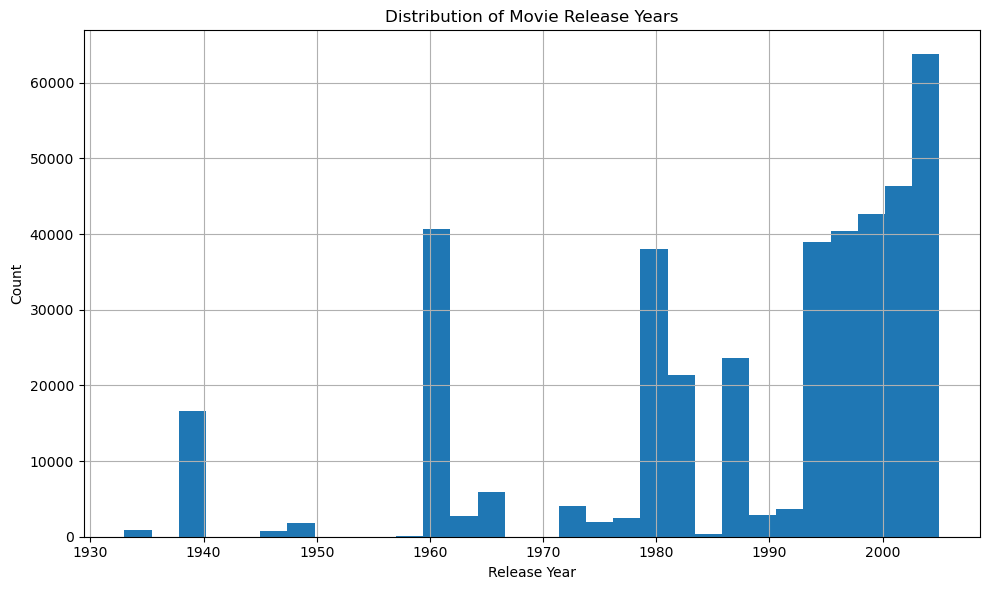

In [224]:
plt.figure(figsize=(10, 6))
nflix_training["release_year"].dropna().hist(bins=30)
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Distribution of Movie Release Years")
plt.tight_layout()
plt.show()

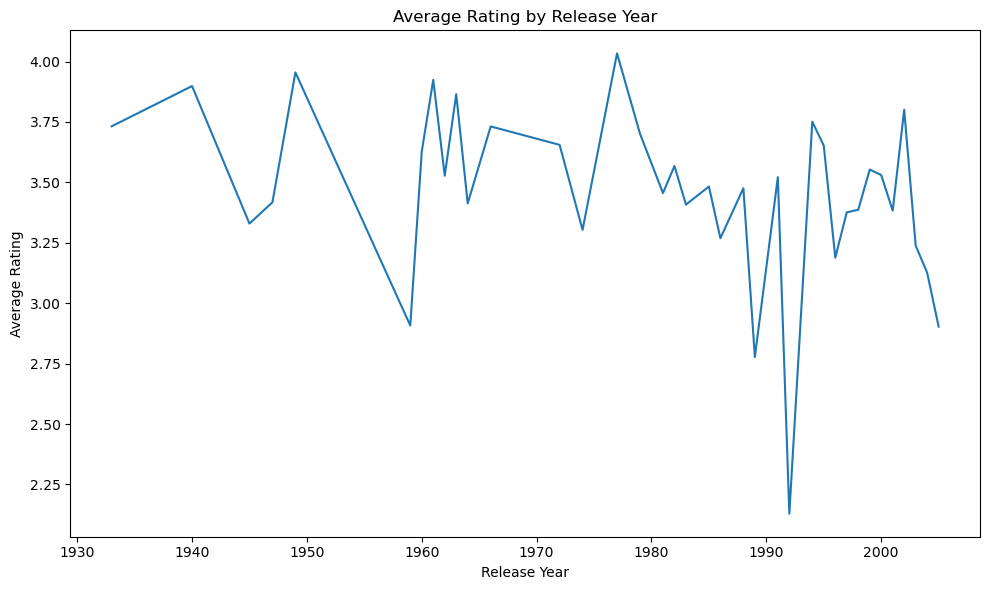

In [225]:
avg_rating_by_year = (nflix_training.groupby("release_year")["rating"].mean()
    .dropna()
)

plt.figure(figsize=(10, 6))
avg_rating_by_year.plot()
plt.xlabel("Release Year")
plt.ylabel("Average Rating")
plt.title("Average Rating by Release Year")
plt.tight_layout()
plt.show()